# Vectorized GBM Backtest

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from boosting_utils import (
    FEATURES, baseline_models, ensure_output_dir, fit_best_classifier, fit_regressor,
    long_short_backtest, make_boosting_panel, make_intraday_features, model_interpretation,
    score_quantiles, tune_gbm
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_boosting_panel(seed=129)
_, scored, _ = fit_best_classifier(panel)
backtest = long_short_backtest(scored)
summary = pd.Series({'periods': len(backtest), 'mean_return': backtest.strategy_return.mean(), 'volatility': backtest.strategy_return.std(), 'ending_equity': backtest.equity_curve.iloc[-1]})
backtest.to_parquet(OUTPUT / 'boosting_long_short_backtest.parquet')
summary.to_csv(OUTPUT / 'boosting_long_short_summary.csv')
summary.to_frame('value')

,value
periods,172.0000
mean_return,0.0024
volatility,0.0095
ending_equity,1.5084


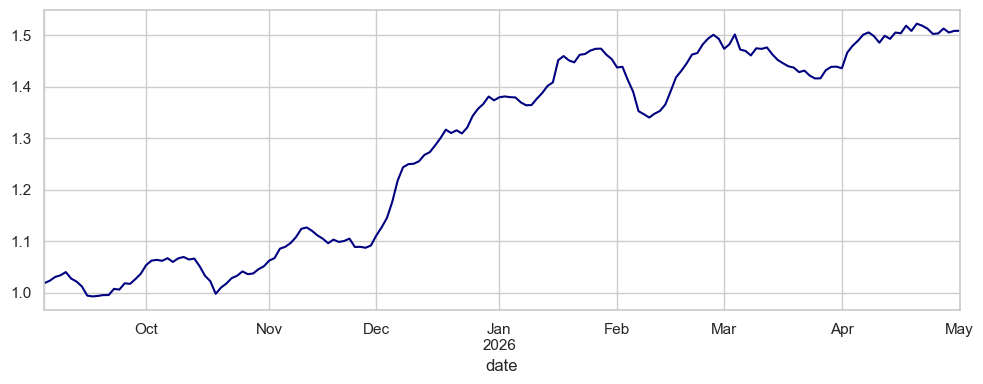

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
backtest.equity_curve.plot(ax=ax, color='navy')
plt.tight_layout()